# 🏦 Fake Banking APK Detection
### Dataset: TUANDROMD (Tezpur University Android Malware Dataset)
- **Samples:** 4,465 (3,365 malicious + 1,000 benign)
- **Features:** 241 static features (permissions, API calls)
- **Target:** `Category` → `malware` or `goodware`
- **Source:** Published IEEE paper — Borah et al., 2020

---
## 📋 Pipeline Overview
1. Install & Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Feature Selection
6. Train 4 Models
7. Evaluate & Compare
8. Cross Validation
9. SHAP Explainability
10. Save Best Model

In [1]:
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../Datasets/TUANDROMD.csv')

In [3]:
df.head()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4465 entries, 0 to 4464
Columns: 242 entries, ACCESS_ALL_DOWNLOADS to Label
dtypes: float64(242)
memory usage: 8.2 MB


In [5]:
df.describe()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
count,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,...,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000
mean,0.000896,0.000896,0.004928,0.083333,0.006944,0.087814,0.022849,0.023746,0.000224,0.596326,...,0.173163,0.245520,0.215950,0.091622,0.088710,0.056228,0.133065,0.013665,0.150090,0.798611
std,0.029924,0.029924,0.070037,0.276416,0.083053,0.283055,0.149440,0.152272,0.014967,0.490689,...,0.378431,0.430443,0.411526,0.288524,0.284356,0.230387,0.339682,0.116108,0.357199,0.401083
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.columns

Index(['ACCESS_ALL_DOWNLOADS', 'ACCESS_CACHE_FILESYSTEM',
       'ACCESS_CHECKIN_PROPERTIES', 'ACCESS_COARSE_LOCATION',
       'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION',
       'ACCESS_LOCATION_EXTRA_COMMANDS', 'ACCESS_MOCK_LOCATION',
       'ACCESS_MTK_MMHW', 'ACCESS_NETWORK_STATE',
       ...
       'Landroid/telephony/TelephonyManager;->getLine1Number',
       'Landroid/telephony/TelephonyManager;->getNetworkOperator',
       'Landroid/telephony/TelephonyManager;->getNetworkOperatorName',
       'Landroid/telephony/TelephonyManager;->getNetworkCountryIso',
       'Landroid/telephony/TelephonyManager;->getSimOperator',
       'Landroid/telephony/TelephonyManager;->getSimOperatorName',
       'Landroid/telephony/TelephonyManager;->getSimCountryIso',
       'Landroid/telephony/TelephonyManager;->getSimSerialNumber',
       'Lorg/apache/http/impl/client/DefaultHttpClient;->execute', 'Label'],
      dtype='object', length=242)

In [7]:
df.nunique()

ACCESS_ALL_DOWNLOADS                                        2
ACCESS_CACHE_FILESYSTEM                                     2
ACCESS_CHECKIN_PROPERTIES                                   2
ACCESS_COARSE_LOCATION                                      2
ACCESS_COARSE_UPDATES                                       2
                                                           ..
Landroid/telephony/TelephonyManager;->getSimOperatorName    2
Landroid/telephony/TelephonyManager;->getSimCountryIso      2
Landroid/telephony/TelephonyManager;->getSimSerialNumber    2
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    2
Label                                                       2
Length: 242, dtype: int64

In [8]:
df.nunique().sum()

np.int64(442)

In [9]:
df.sum()

ACCESS_ALL_DOWNLOADS                                           4.0
ACCESS_CACHE_FILESYSTEM                                        4.0
ACCESS_CHECKIN_PROPERTIES                                     22.0
ACCESS_COARSE_LOCATION                                       372.0
ACCESS_COARSE_UPDATES                                         31.0
                                                             ...  
Landroid/telephony/TelephonyManager;->getSimOperatorName     251.0
Landroid/telephony/TelephonyManager;->getSimCountryIso       594.0
Landroid/telephony/TelephonyManager;->getSimSerialNumber      61.0
Lorg/apache/http/impl/client/DefaultHttpClient;->execute     670.0
Label                                                       3565.0
Length: 242, dtype: float64

In [10]:
df.isnull().value_counts()

ACCESS_ALL_DOWNLOADS  ACCESS_CACHE_FILESYSTEM  ACCESS_CHECKIN_PROPERTIES  ACCESS_COARSE_LOCATION  ACCESS_COARSE_UPDATES  ACCESS_FINE_LOCATION  ACCESS_LOCATION_EXTRA_COMMANDS  ACCESS_MOCK_LOCATION  ACCESS_MTK_MMHW  ACCESS_NETWORK_STATE  ACCESS_PROVIDER  ACCESS_SERVICE  ACCESS_SHARED_DATA  ACCESS_SUPERUSER  ACCESS_SURFACE_FLINGER  ACCESS_WIFI_STATE  activityCalled  ACTIVITY_RECOGNITION  ACCOUNT_MANAGER  ADD_VOICEMAIL  ANT    ANT_ADMIN  AUTHENTICATE_ACCOUNTS  AUTORUN_MANAGER_LICENSE_MANAGER  AUTORUN_MANAGER_LICENSE_SERVICE(.autorun)  BATTERY_STATS  BILLING  BIND_ACCESSIBILITY_SERVICE  BIND_APPWIDGET  BIND_CARRIER_MESSAGING_SERVICE  BIND_DEVICE_ADMIN  BIND_DREAM_SERVICE  BIND_GET_INSTALL_REFERRER_SERVICE  BIND_INPUT_METHOD  BIND_NFC_SERVICE  BIND_0TIFICATION_LISTENER_SERVICE  BIND_PRINT_SERVICE  BIND_REMOTEVIEWS  BIND_TEXT_SERVICE  BIND_TV_INPUT  BIND_VOICE_INTERACTION  BIND_VPN_SERVICE  BIND_WALLPAPER  BLUETOOTH  BLUETOOTH_ADMIN  BLUETOOTH_PRIVILEGED  BODY_SENSORS  BRICK  BROADCAST_PACKAG

In [11]:
df.isnull().sum()

ACCESS_ALL_DOWNLOADS                                        1
ACCESS_CACHE_FILESYSTEM                                     1
ACCESS_CHECKIN_PROPERTIES                                   1
ACCESS_COARSE_LOCATION                                      1
ACCESS_COARSE_UPDATES                                       1
                                                           ..
Landroid/telephony/TelephonyManager;->getSimOperatorName    1
Landroid/telephony/TelephonyManager;->getSimCountryIso      1
Landroid/telephony/TelephonyManager;->getSimSerialNumber    1
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    1
Label                                                       1
Length: 242, dtype: int64

In [12]:
df.shape

(4465, 242)

In [13]:
df.shape[0]

4465

In [14]:
for col in df.columns:
    print(f'{col} column unique values are : {df[col].unique()}')

ACCESS_ALL_DOWNLOADS column unique values are : [ 0. nan  1.]
ACCESS_CACHE_FILESYSTEM column unique values are : [ 0. nan  1.]
ACCESS_CHECKIN_PROPERTIES column unique values are : [ 0.  1. nan]
ACCESS_COARSE_LOCATION column unique values are : [ 0.  1. nan]
ACCESS_COARSE_UPDATES column unique values are : [ 0.  1. nan]
ACCESS_FINE_LOCATION column unique values are : [ 0.  1. nan]
ACCESS_LOCATION_EXTRA_COMMANDS column unique values are : [ 0.  1. nan]
ACCESS_MOCK_LOCATION column unique values are : [ 0.  1. nan]
ACCESS_MTK_MMHW column unique values are : [ 0. nan  1.]
ACCESS_NETWORK_STATE column unique values are : [ 1.  0. nan]
ACCESS_PROVIDER column unique values are : [ 0. nan]
ACCESS_SERVICE column unique values are : [ 0. nan]
ACCESS_SHARED_DATA column unique values are : [ 0. nan]
ACCESS_SUPERUSER column unique values are : [ 0.  1. nan]
ACCESS_SURFACE_FLINGER column unique values are : [ 0.  1. nan]
ACCESS_WIFI_STATE column unique values are : [ 0.  1. nan]
activityCalled column 

In [15]:
label_col = None

for col in df.columns:
    
    if df[col].dtype == 'object' or col.lower in ['label', 'class', 'target', 'category']:
        label_col = col
        break
    
    if label_col is None:
        label_col = df.columns[-1]
        

print(f'label col is {label_col}')
print(f'Unique values: {df[label_col].unique()}')

print(f'\n Class Distribution:')
print(df[label_col].value_counts())
print(f'\n Class Percentage:')
print(df[label_col].value_counts(normalize=True).round(3) * 100)

    

label col is Label
Unique values: [ 1. nan  0.]

 Class Distribution:
Label
1.0    3565
0.0     899
Name: count, dtype: int64

 Class Percentage:
Label
1.0    79.9
0.0    20.1
Name: proportion, dtype: float64


# Check NULL values

In [16]:

print(f'\n Total missing values: {df.isnull().sum().sum()}')


print(f'Columns with missing values:\n{df.isnull().sum() }')


print(f'Data Types:')
print(df.dtypes.value_counts())

print(f'\n Basic Statistics : ')
feature_cols = [c for c in df.columns if c != label_col]
df[feature_cols].describe().round(2)


 Total missing values: 242
Columns with missing values:
ACCESS_ALL_DOWNLOADS                                        1
ACCESS_CACHE_FILESYSTEM                                     1
ACCESS_CHECKIN_PROPERTIES                                   1
ACCESS_COARSE_LOCATION                                      1
ACCESS_COARSE_UPDATES                                       1
                                                           ..
Landroid/telephony/TelephonyManager;->getSimOperatorName    1
Landroid/telephony/TelephonyManager;->getSimCountryIso      1
Landroid/telephony/TelephonyManager;->getSimSerialNumber    1
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    1
Label                                                       1
Length: 242, dtype: int64
Data Types:
float64    242
Name: count, dtype: int64

 Basic Statistics : 


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
count,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,...,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00,4464.00
mean,0.00,0.00,0.00,0.08,0.01,0.09,0.02,0.02,0.00,0.60,...,0.05,0.17,0.25,0.22,0.09,0.09,0.06,0.13,0.01,0.15
std,0.03,0.03,0.07,0.28,0.08,0.28,0.15,0.15,0.01,0.49,...,0.22,0.38,0.43,0.41,0.29,0.28,0.23,0.34,0.12,0.36
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [17]:
# df.fillna(df.mean())     # numeric
# df.fillna("Unknown")     # categorical

In [18]:
df = df.dropna()

In [19]:
df.isnull().sum()

ACCESS_ALL_DOWNLOADS                                        0
ACCESS_CACHE_FILESYSTEM                                     0
ACCESS_CHECKIN_PROPERTIES                                   0
ACCESS_COARSE_LOCATION                                      0
ACCESS_COARSE_UPDATES                                       0
                                                           ..
Landroid/telephony/TelephonyManager;->getSimOperatorName    0
Landroid/telephony/TelephonyManager;->getSimCountryIso      0
Landroid/telephony/TelephonyManager;->getSimSerialNumber    0
Lorg/apache/http/impl/client/DefaultHttpClient;->execute    0
Label                                                       0
Length: 242, dtype: int64

# ──────  Visualize class distribution ────────


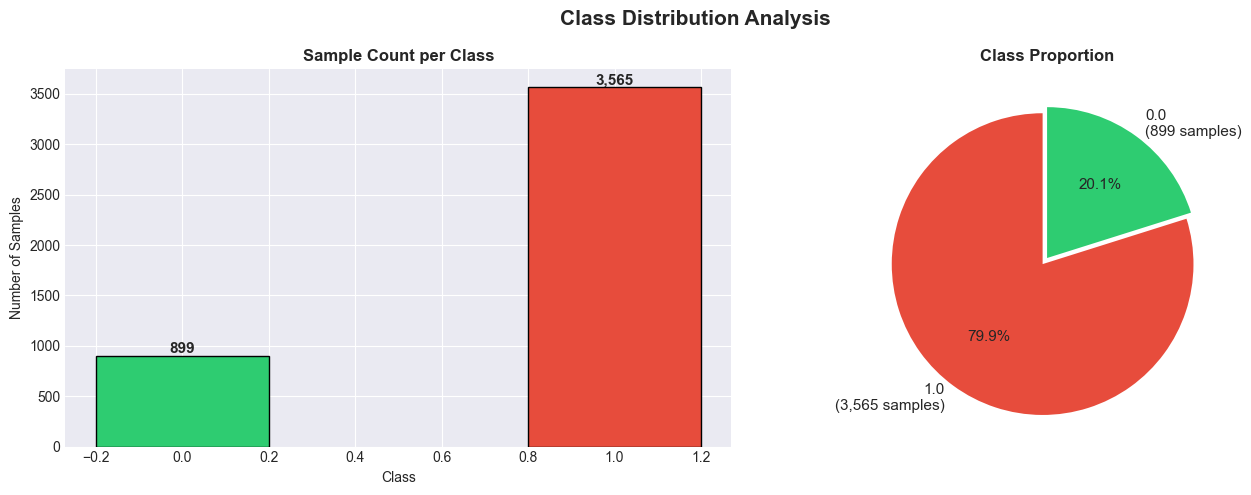

⚠️  IMBALANCED DATASET — 75% malicious vs 25% benign!
   → We will use SMOTE to fix this in preprocessing


In [20]:
# ── 4c. Visualize class distribution ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution Analysis', fontsize=15, fontweight='bold')

# Bar chart
class_counts = df[label_col].value_counts()
colors = ['#e74c3c', '#2ecc71']  # red=malware, green=goodware
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=colors, edgecolor='black', width=0.4)
axes[0].set_title('Sample Count per Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 30,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(class_counts.values,
            labels=[f'{c}\n({v:,} samples)' for c, v in zip(class_counts.index, class_counts.values)],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0),
            textprops={'fontsize': 11})
axes[1].set_title('Class Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  IMBALANCED DATASET — 75% malicious vs 25% benign!')
print('   → We will use SMOTE to fix this in preprocessing')

In [29]:
df[label_col]

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
4460    0.0
4461    0.0
4462    0.0
4463    0.0
4464    0.0
Name: Label, Length: 4464, dtype: float64

In [21]:
feature_cols = [c for c in df.columns if c != label_col]
binary_feats = [c for c in feature_cols if df[c].nunique() <= 2]
multi_feats  = [c for c in feature_cols if df[c].nunique() > 2]

print(f'> Feature Types:')
print(f'   Binary features (0/1):     {len(binary_feats)}')
print(f'   Multi-value features:      {len(multi_feats)}')
print(f'   Total features:            {len(feature_cols)}')

# Show top 10 most activated permissions in malware vs benign
X_all  = df[feature_cols]
y_text = df[label_col]




> Feature Types:
   Binary features (0/1):     241
   Multi-value features:      0
   Total features:            241


In [22]:
malware_mask  = y_text == 'malware'
goodware_mask = y_text == 'goodware'

# Mean activation per class for top 20 features
malware_means  = X_all[malware_mask].mean().nlargest(20)
goodware_means = X_all[goodware_mask].mean()[malware_means.index]

comparison_df = pd.DataFrame({
    'Malware':  malware_means.values,
    'Goodware': goodware_means.values
}, index=malware_means.index)




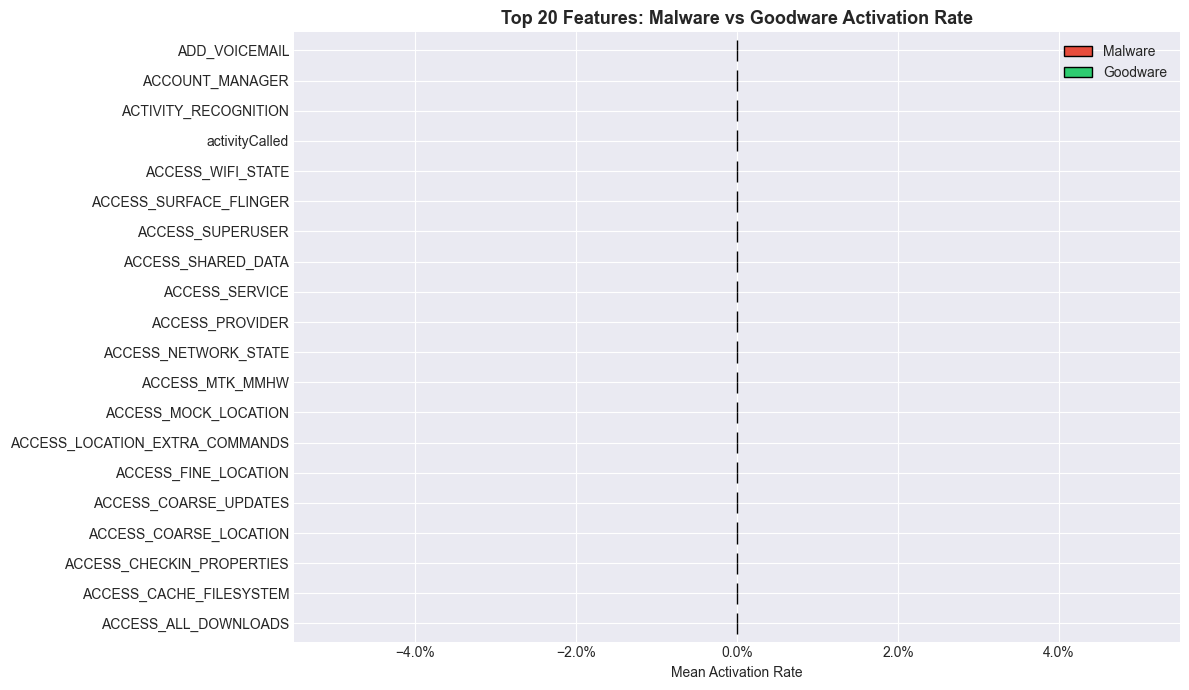

In [23]:


fig, ax = plt.subplots(figsize=(12, 7))
comparison_df.plot(kind='barh', ax=ax,
                   color=['#e74c3c', '#2ecc71'],
                   edgecolor='black', width=0.7)
ax.set_title('Top 20 Features: Malware vs Goodware Activation Rate',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Activation Rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('02_feature_activation.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
df.to_csv('../Datasets/prepared_dataset.csv')

In [28]:
df['Label']

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
4460    0.0
4461    0.0
4462    0.0
4463    0.0
4464    0.0
Name: Label, Length: 4464, dtype: float64